*** ETL ON OPENWEATHER ***


In [ ]:
# import libraries
!pip install pycountry
import pandas as pd
import requests as rt
import openpyxl as xl
import numpy as np
from datetime import datetime
import pycountry as pct
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Extraction
# 9 Cities

api_key = "45336913fbae1169d426658500209a8b"
cities = ("Lagos", "Abeokuta", "Osun", "Ilorin", "Abuja", "Abia", "Edo", "Port Harcourt", "Mowe")
all_weather_data = []

for city_name in cities:
    # Correct OpenWeatherMap API endpoint for current weather data
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city_name}&appid={api_key}&units=metric"
    response = rt.get(url)

    if response.status_code == 200:
        data = response.json()
        all_weather_data.append(data)
        print(f"Successfully fetched data for {city_name}")
    else:
        print(f"Error fetching data for {city_name}: {response.status_code} - {response.text}")

Successfully fetched data for Lagos
Successfully fetched data for Abeokuta
Successfully fetched data for Osun
Successfully fetched data for Ilorin
Successfully fetched data for Abuja
Successfully fetched data for Abia
Successfully fetched data for Edo
Successfully fetched data for Port Harcourt
Successfully fetched data for Mowe


In [ ]:
#dataset
extracted_data = []

for city_data in all_weather_data:
    weather_entry = {
        "Cities": city_data["name"],
        "Country": city_data["sys"]["country"],
        "Weather": city_data["weather"][0]["description"],
        "Temperature": city_data["main"]["temp"],
        "Humidity": city_data["main"]["humidity"],
        "Wind_Speed": city_data["wind"]["speed"],
        "Date Time": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
    extracted_data.append(weather_entry)

df = pd.DataFrame(extracted_data)
print(df.head())

     Cities Country          Weather  Temperature  Humidity  Wind_Speed  \
0     Lagos      NG       light rain        24.43        94        1.74   
1  Abeokuta      NG       light rain        23.78        96        2.19   
2      Osun      NG    moderate rain        21.36        97        1.79   
3    Ilorin      NG    moderate rain        23.70        92        3.73   
4     Abuja      NG  overcast clouds        23.55        90        1.68   

             Date Time  
0  2026-06-20 21:27:14  
1  2026-06-20 21:27:14  
2  2026-06-20 21:27:14  
3  2026-06-20 21:27:14  
4  2026-06-20 21:27:14  


In [ ]:
print(df.dtypes)

Cities          object
Country         object
Weather         object
Temperature    float64
Humidity         int64
Wind_Speed     float64
Date Time       object
dtype: object


In [ ]:
#Check NULL VALUES
df.isnull().sum()

,0
Cities,0
Country,0
Weather,0
Temperature,0
Humidity,0
Wind_Speed,0
Date Time,0


In [ ]:
#FIND DUPLICATES AND DROP
print(df.duplicated())
df.drop_duplicates(inplace = True)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
dtype: bool


In [ ]:
#renaming date coumn to timestamp
df.rename(columns = {"Date Time": "TimeStamp"}, inplace = True)
df.head()

,Cities,Country,Weather,Temperature,Humidity,Wind_Speed,TimeStamp
0,Lagos,NG,light rain,24.43,94,1.74,2026-06-20 21:27:14
1,Abeokuta,NG,light rain,23.78,96,2.19,2026-06-20 21:27:14
2,Osun,NG,moderate rain,21.36,97,1.79,2026-06-20 21:27:14
3,Ilorin,NG,moderate rain,23.70,92,3.73,2026-06-20 21:27:14
4,Abuja,NG,overcast clouds,23.55,90,1.68,2026-06-20 21:27:14


In [ ]:
# download as csv and excel file
df.to_csv("weather_data.csv", index = False)
df.to_excel("weather_data.xlsx", index = False)

Weather Analysis

In [ ]:
#city with highest temperature
highest_temperature = df.loc[df.idxmax()["Temperature"]]
print(f"City with highest temperature is {highest_temperature['Cities']}")

City with highest temperature is Mowe


In [ ]:
#City with lowest temperature
lowest_temperature = df.loc[df.idxmin()["Temperature"]]
print(f"City with lowest temperature is {lowest_temperature['Cities']}")

City with lowest temperature is Abia


In [ ]:
#Most humid city
humid_city = df.loc[df.idxmax()["Humidity"]]
print(f"City with highest humidity is {humid_city['Cities']}")

City with highest humidity is Edo


In [ ]:
#Least Humid city
least_humid_city = df.loc[df.idxmin()["Humidity"]]
print(f"City with lowest humidity is {least_humid_city['Cities']}")

City with lowest humidity is Abia


In [ ]:
#Average temperature
avg_temperature = df["Temperature"].mean()
print(f"The average temperature is {avg_temperature:.2f}")

The average temperature is 21.97


In [ ]:
#City with highest wind speed
highest_wind_speed = df.loc[df.idxmax()["Wind_Speed"]]
print(f"City with highest wind speed is {highest_wind_speed['Cities']}")

City with highest wind speed is Ilorin


In [ ]:
#City with lowest wind speed
lowest_wind_speed = df.loc[df.idxmin()["Wind_Speed"]]
print(f"City with lowest wind speed is {lowest_wind_speed['Cities']}")

City with lowest wind speed is Abuja


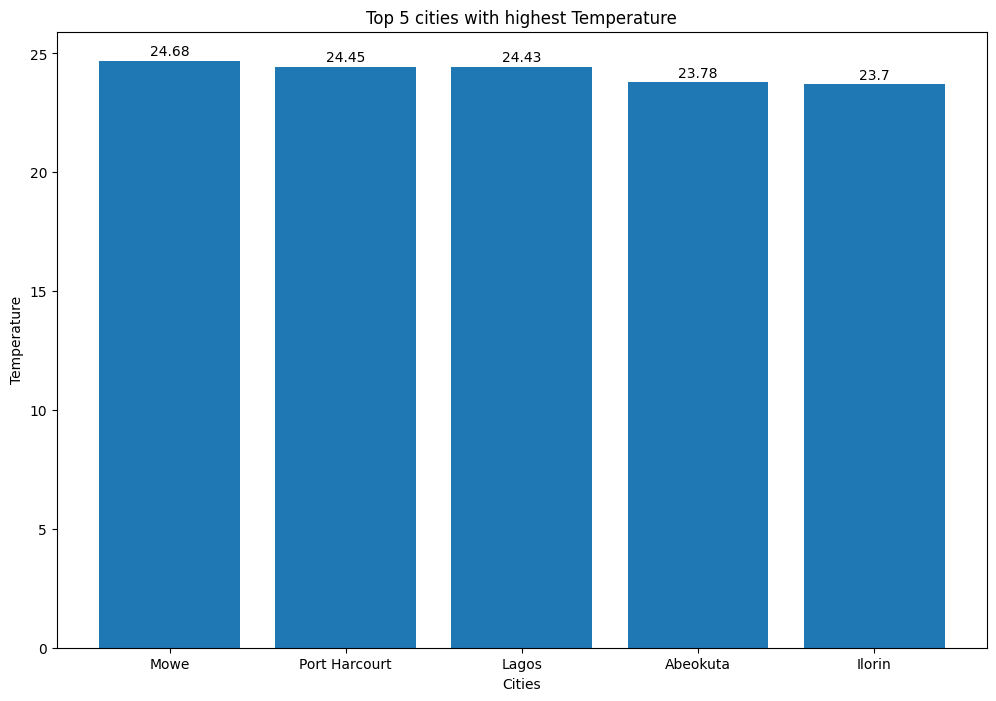

In [ ]:
top_5 = df.sort_values(by='Temperature', ascending=False).head(5)
plt.figure(figsize=(12,8))
bars = plt.bar(top_5["Cities"], top_5["Temperature"])
plt.title("Top 5 cities with highest Temperature")
plt.xlabel("Cities")
plt.ylabel("Temperature")

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom') # +0.1 to place label slightly above bar

plt.show()

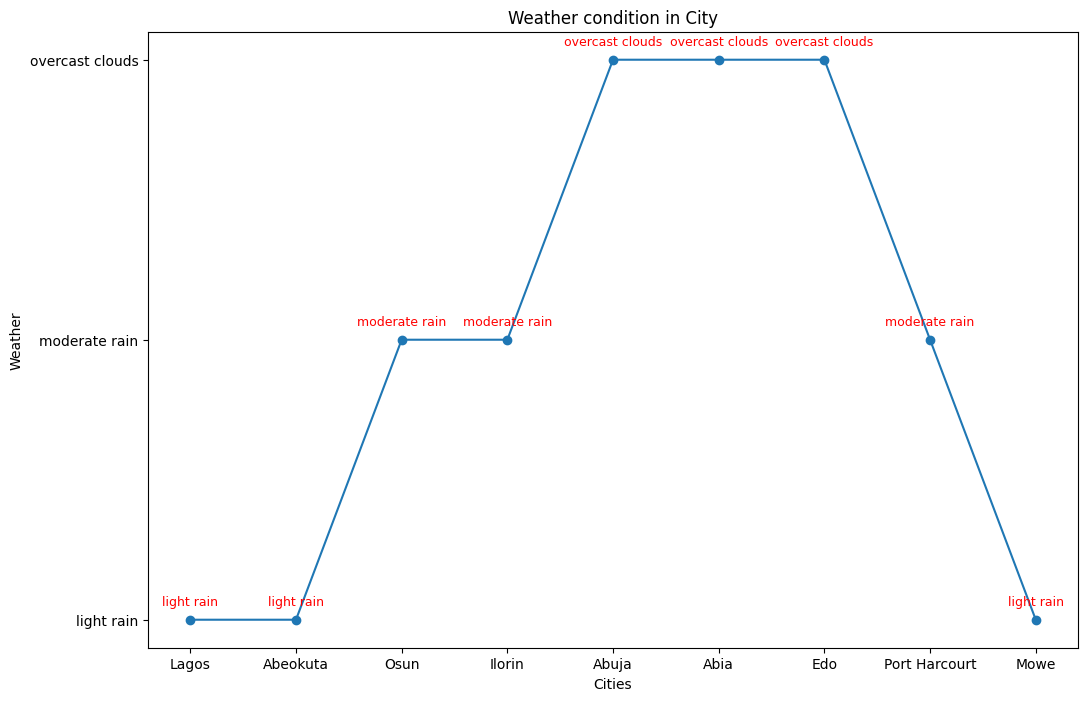

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(df["Cities"], df["Weather"], marker='o')
plt.title("Weather condition in City")
plt.xlabel("Cities")
plt.ylabel("Weather")


for i, row in df.iterrows():
    plt.annotate(
        row['Weather'],
        (row['Cities'], row['Weather']),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        color='red'
    )

plt.show()

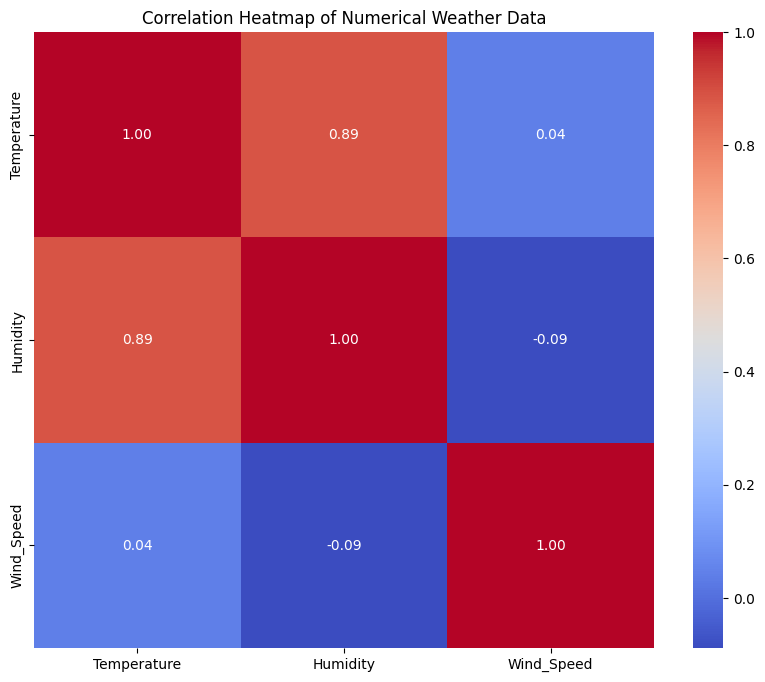

In [ ]:
numerical_df = df.select_dtypes(include=['number'])


correlation_matrix = numerical_df.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Weather Data')
plt.show()